In [1]:
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import rasterio as rio
from rasterio.enums import Resampling
import json
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from PIL import ImageColor
import skimage as ski
from skimage.exposure import rescale_intensity
import scipy
from rasterio.features import shapes

In [2]:
lc_dir = 'label.json'
sample_dir = "sample.geojson"

In [4]:
import pandas as pd

lc = json.load(open(lc_dir))
lc_df = pd.DataFrame(lc)
lc_df["values_normalize"] = lc_df.index + 1
lc_df["palette"] = "#" + lc_df["palette"]

values = lc_df["values"].to_list()
values_n = lc_df["values_normalize"].to_list()
palette = lc_df["palette"].to_list()
labels = lc_df["label"].to_list()

dict_value = {}
dict_label = {}
dict_palette = {}
dict_palette_hex = {}

for x in range(0, len(values)):
    dict_value[values[x]] = values_n[x]
    dict_label[values_n[x]] = labels[x]
    p = palette[x]
    p = '#' + p.lstrip('#')
    palette[x] = p
    dict_palette[values_n[x]] = ImageColor.getrgb(p)
    dict_palette_hex[values_n[x]] = palette[x]

cmap = ListedColormap(palette)

patches = [
    mpatches.Patch(color=palette[i], label=labels[i]) for i in range(len(values))
]

legend = {
    "handles":patches,
    "bbox_to_anchor":(1.05, 1),
    "loc":2,
    "borderaxespad":0.0,
}

lc_df

,palette,values,label,values_normalize
0,##228B22,101,Vegetation,1
1,##D2B48C,102,Bare land,2
2,##FF0000,103,Residence area,3
3,##800080,104,Industry,4
4,##1E90FF,105,Water bodies,5


c:\Users\AdnanYusufHartawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Integer values probably ranging out of 64bit integer range have been found. Will be clamped to INT64_MIN/INT64_MAX
  return ogr_read(
c:\Users\AdnanYusufHartawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Several features with id = 248 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


(273, 5)


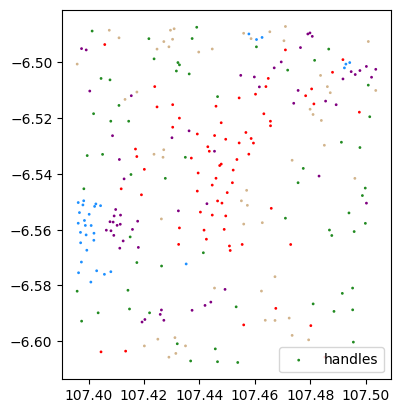

In [5]:
sample = gpd.read_file(sample_dir)
sample["value"] = sample["lc"].map(dict_value)
sample["label"] = sample["value"].map(dict_label)

sample.plot(column="value", cmap=cmap, markersize=1)
plt.legend(legend)

sample_extract = sample.copy()
coords = [
    (x,y) for x, y in zip(sample_extract["geometry"].x, sample_extract["geometry"].y)
]

print(sample_extract.shape)

In [38]:
import os, glob

landsat_dirr = "landsat_dir"
if os.path.isdir(landsat_dirr):
    tif_files = sorted(glob.glob(os.path.join(landsat_dirr, "*.tif")))
    if not tif_files:
        raise FileNotFoundError(f"No .tif files found in directory {landsat_dirr!r}")
    landsat_image = rio.open(tif_files[0])
else:
    landsat_image = rio.open(landsat_dirr)
landsat_image = landsat_image.read() / 1e4

-0.0031962500000000116 1.289015 0.10699482177614203


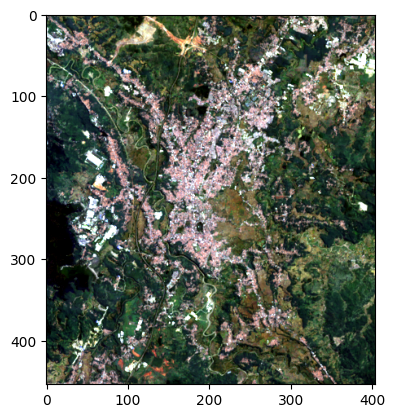

,id,lc,geometry,value,label,Purwakarta_SR_B1,Purwakarta_SR_B2,Purwakarta_SR_B3,Purwakarta_SR_B4,Purwakarta_SR_B5,Purwakarta_SR_B6,Purwakarta_SR_B7
0,0,101,POINT (107.43493 -6.53404),1.0,Vegetation,0.020797,0.024482,0.042522,0.028470,0.284743,0.114407,0.045327
1,1,101,POINT (107.42771 -6.54159),1.0,Vegetation,0.031385,0.032732,0.052478,0.036032,0.380085,0.199547,0.081875
2,2,101,POINT (107.4153 -6.54021),1.0,Vegetation,0.033200,0.031853,0.049150,0.030890,0.363805,0.171965,0.068675
3,3,101,POINT (107.39951 -6.53342),1.0,Vegetation,0.024592,0.025184,0.039099,0.023190,0.341228,0.129065,0.045231
4,4,101,POINT (107.3983 -6.54533),1.0,Vegetation,0.033255,0.032320,0.052409,0.034864,0.387524,0.206670,0.085423
...,...,...,...,...,...,...,...,...,...,...,...,...
268,266,105,POINT (107.43523 -6.57229),5.0,Water bodies,0.014046,0.017552,0.027453,0.019216,0.019684,0.006566,0.005562
269,267,105,POINT (107.4019 -6.5638),5.0,Water bodies,0.005012,0.010966,0.028951,0.019464,0.049535,0.030381,0.017346
270,268,105,POINT (107.39708 -6.56096),5.0,Water bodies,0.009110,0.014239,0.030766,0.025280,0.051515,0.028126,0.019904
271,269,105,POINT (107.39884 -6.55848),5.0,Water bodies,0.004958,0.010251,0.023974,0.017016,0.033076,0.018501,0.012561


In [50]:
out_range = (0, 1)

stacked = []
for f in tif_files:
    with rio.open(f) as src:
        band = src.read(1).astype(float)
        stacked.append(band)  # tanpa rumus skala apapun
        landsat_transform = src.transform
landsat_image = np.stack(stacked, axis=0)

print(landsat_image.min(), landsat_image.max(), landsat_image.mean())  # cek dulu sebelum render

def stretch(band, p_low=2, p_high=98):
    lo, hi = np.percentile(band, (p_low, p_high))
    return rescale_intensity(band, in_range=(lo, hi), out_range=(0, 1))

red   = stretch(landsat_image[3])
green = stretch(landsat_image[2])
blue  = stretch(landsat_image[1])

arr_image = np.stack([red, green, blue], axis=-1)
composite = arr_image
plt.imshow(composite)
plt.show()

band_names = [
    "Purwakarta_SR_B1",
    "Purwakarta_SR_B2",
    "Purwakarta_SR_B3",
    "Purwakarta_SR_B4",
    "Purwakarta_SR_B5",
    "Purwakarta_SR_B6",
    "Purwakarta_SR_B7",
]
rows, cols = rio.transform.rowcol(
    landsat_transform,
    [x for x, y in coords],
    [y for x, y in coords],
)
landsat_extract = np.stack(
    [landsat_image[i, rows, cols] for i in range(len(band_names))],
    axis=1,
)

sample_extract[band_names] = landsat_extract
sample_extract

In [51]:
seeds = 2 
train, test = train_test_split(sample_extract, train_size=0.7, random_state=seeds)
print(f"train size :{len(train)} \n test size : {len(test)}")

train size :191 
 test size : 82


In [52]:
prediksi = ["Purwakarta_SR_B1","Purwakarta_SR_B2","Purwakarta_SR_B3","Purwakarta_SR_B4","Purwakarta_SR_B5","Purwakarta_SR_B6","Purwakarta_SR_B7"]
model = RandomForestClassifier()
model.fit(
    train[prediksi],
    train["value"]
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


                precision    recall  f1-score   support

    Vegetation       1.00      1.00      1.00        18
     Bare land       1.00      1.00      1.00        18
Residence area       1.00      1.00      1.00        24
      Industry       1.00      1.00      1.00        15
  Water bodies       1.00      1.00      1.00         6

      accuracy                           1.00        81
     macro avg       1.00      1.00      1.00        81
  weighted avg       1.00      1.00      1.00        81



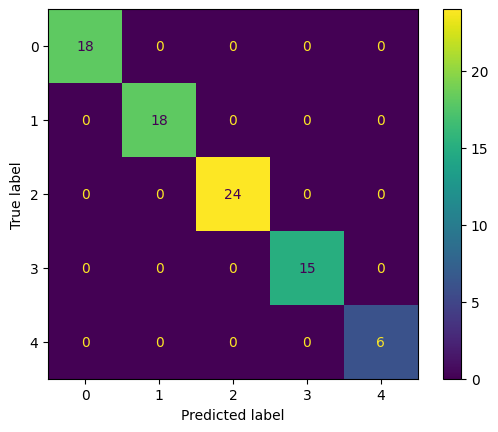

In [53]:
test_apply = model.predict(test[prediksi])
mask = test["value"].notna()
y_true = test["value"][mask].astype(int)
y_pred = test_apply[mask.values].astype(int)
cm = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(cm)
display.plot()

report = classification_report(y_true, y_pred, target_names=labels)
print(report)

In [60]:
bands, rows, cols = landsat_image.shape
table_image = pd.DataFrame(
    landsat_image.reshape(bands, -1).T,
    columns=band_names,
)
table_image

,Purwakarta_SR_B1,Purwakarta_SR_B2,Purwakarta_SR_B3,Purwakarta_SR_B4,Purwakarta_SR_B5,Purwakarta_SR_B6,Purwakarta_SR_B7
0,0.022448,0.026105,0.049177,0.034520,0.317742,0.143612,0.061195
1,0.026847,0.031000,0.052698,0.037958,0.324590,0.170370,0.078547
2,0.032925,0.034960,0.057400,0.048242,0.277647,0.187585,0.097440
3,0.046758,0.051872,0.074752,0.084295,0.241485,0.205405,0.146307
4,0.053825,0.060150,0.083498,0.094580,0.201060,0.204030,0.156180
...,...,...,...,...,...,...,...
183411,0.022915,0.022475,0.040020,0.023547,0.311926,0.142389,0.055791
183412,0.021952,0.021540,0.035166,0.020605,0.284110,0.130234,0.051886
183413,0.022695,0.021733,0.035070,0.022420,0.282804,0.143310,0.059366
183414,0.023121,0.023053,0.040474,0.025376,0.321785,0.156551,0.063794


In [61]:
prediction = model.predict(table_image[prediksi])
prediction

array([1., 1., 1., ..., 1., 1., 1.], shape=(183416,))

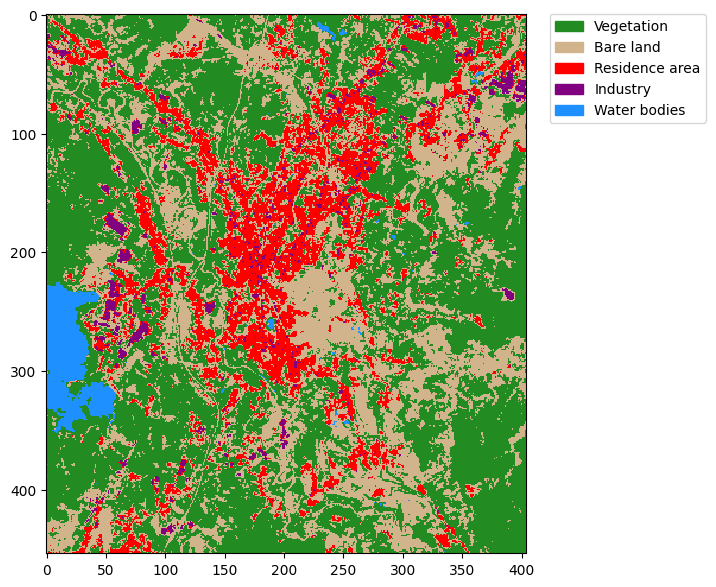

In [69]:
# NumPy automatically determines the second dimension size
reshaped_prediction = prediction.reshape(rows,cols)

# Apply the transformations
prediction_image = reshaped_prediction

# Show plot
plt.figure(figsize=(7, 7))
plt.imshow(prediction_image, cmap=cmap, interpolation="nearest")
plt.legend(**legend)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


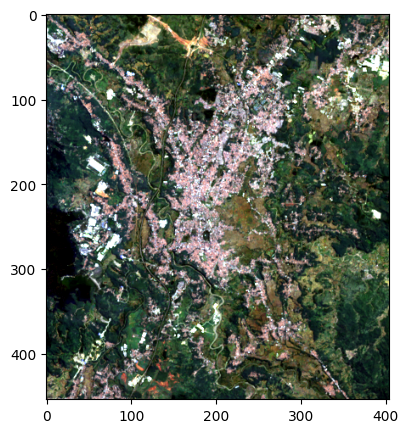

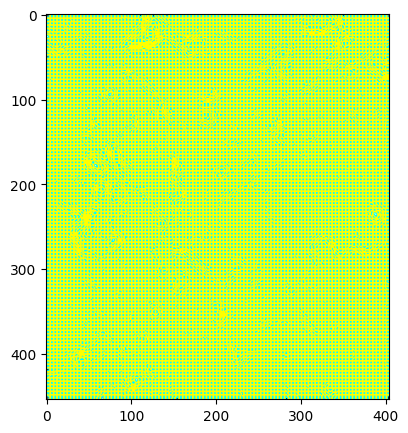

In [63]:
seed_image = composite
plt.figure(figsize=(5, 5))
plt.imshow(seed_image)

# Segmentation
segment = ski.segmentation.slic(
    seed_image, n_segments=10000, compactness=5, sigma=5
)
plt.figure(figsize=(5, 5))
plt.imshow(ski.segmentation.mark_boundaries(composite, segment, outline_color=(0, 255, 255)))

In [64]:
segment_unique = np.unique(segment)
lc_segment = segment.copy()
for x in segment_unique:
    lc_segment[segment == x] = scipy.stats.mode(prediction_image[segment == x]).mode
lc_segment

array([[2, 2, 2, ..., 3, 3, 3],
       [2, 2, 2, ..., 3, 3, 3],
       [2, 2, 2, ..., 3, 3, 3],
       ...,
       [2, 2, 2, ..., 1, 1, 1],
       [2, 2, 2, ..., 1, 1, 1],
       [2, 2, 2, ..., 1, 1, 1]], shape=(454, 404))

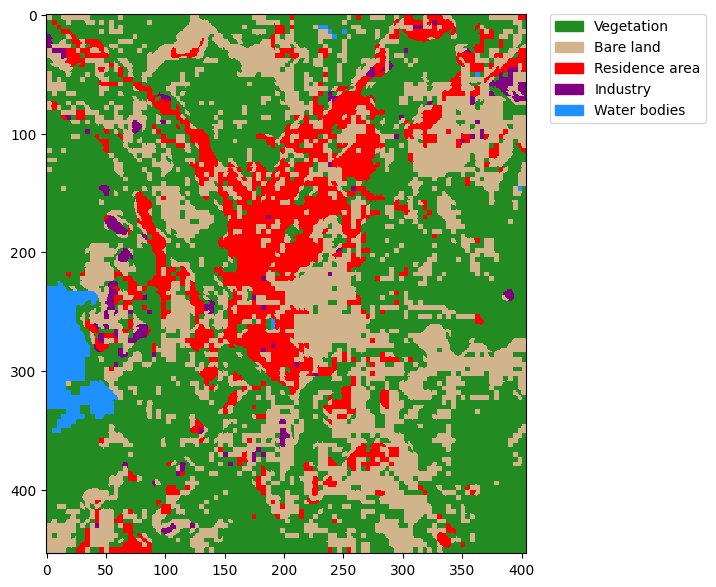

In [68]:
plt.figure(figsize=(7, 7))
plt.imshow(lc_segment, cmap=cmap, interpolation="nearest")
plt.legend(**legend)